In [2]:
from pathlib import Path
import urllib.request
import bz2
import shutil

import dlib
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

Step 1. Specify paths to images

In [3]:
PERSON_IMAGE_PATH = "person.jpg"   
GROUP_IMAGE_PATH = "group.jpg"     


def load_image_rgb(image_path):
    # Loads an image in RGB format
    image_bgr = cv2.imread(image_path)

    if image_bgr is None:
        raise FileNotFoundError(f"Could not open file: {image_path}")

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    return image_rgb


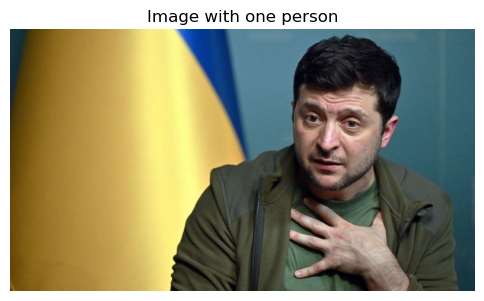

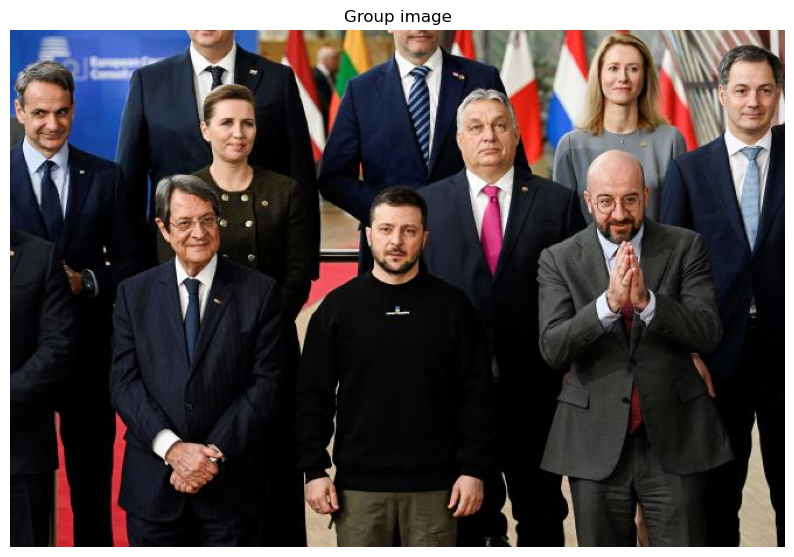

In [4]:
person_img = load_image_rgb(PERSON_IMAGE_PATH)
group_img = load_image_rgb(GROUP_IMAGE_PATH)

plt.figure(figsize=(6, 6))
plt.imshow(person_img)
plt.axis("off")
plt.title("Image with one person")
plt.show()

plt.figure(figsize=(10, 7))
plt.imshow(group_img)
plt.axis("off")
plt.title("Group image")
plt.show()


Step 2. Load the dlib face predictor

In [5]:
PREDICTOR_PATH = Path("shape_predictor_68_face_landmarks.dat")

def download_and_extract_bz2(url, output_path):
    # Downloads a .bz2 file and unpacks it
    compressed_path = output_path.with_suffix(output_path.suffix + ".bz2")

    if output_path.exists():
        print(f"Model already exists: {output_path}")
        return

    print("Downloading model...")
    urllib.request.urlretrieve(url, compressed_path)

    print("Extracting model...")
    with bz2.BZ2File(compressed_path, "rb") as source:
        with open(output_path, "wb") as target:
            shutil.copyfileobj(source, target)

    compressed_path.unlink()
    print(f"Done: {output_path}")


In [6]:
download_and_extract_bz2(
    url="http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2",
    output_path=PREDICTOR_PATH
)


Extracting model...
Done: shape_predictor_68_face_landmarks.dat


In [7]:
face_detector = dlib.get_frontal_face_detector()
shape_predictor = dlib.shape_predictor(str(PREDICTOR_PATH))

Step 3. Run the detector and predictor on your image 

In [8]:
def detect_faces_and_landmarks(image_rgb, upsample_times=1):
    # Finds faces and facial landmarks in an image

    faces = face_detector(image_rgb, upsample_times)

    results = []

    for face in faces:
        landmarks = shape_predictor(image_rgb, face)

        points = []
        for i in range(68):
            point = landmarks.part(i)
            points.append((point.x, point.y))

        results.append({
            "rect": face,
            "landmarks": np.array(points)
        })

    return results


In [9]:
person_results = detect_faces_and_landmarks(person_img, upsample_times=1)
group_results = detect_faces_and_landmarks(group_img, upsample_times=1)


In [10]:
print(f"Faces in person image: {len(person_results)}")
print(f"Faces in group image: {len(group_results)}")


Faces in person image: 1
Faces in group image: 8


Step 4. Draw bounding boxes around detected faces 

In [11]:
def draw_faces(image_rgb, results, title="Detected faces", draw_landmarks=True):
    # Draws bounding boxes in different colors for each face

    colors = plt.cm.tab20(np.linspace(0, 1, max(len(results), 1)))

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(image_rgb)
    ax.axis("off")
    ax.set_title(title)

    for idx, result in enumerate(results):
        rect = result["rect"]
        landmarks = result["landmarks"]
        color = colors[idx % len(colors)]

        x = rect.left()
        y = rect.top()
        w = rect.right() - rect.left()
        h = rect.bottom() - rect.top()

        box = Rectangle(
            (x, y),
            w,
            h,
            linewidth=3,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(box)

        ax.text(
            x,
            y - 8,
            f"Face {idx + 1}",
            color=color,
            fontsize=12,
            weight="bold",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        if draw_landmarks:
            ax.scatter(
                landmarks[:, 0],
                landmarks[:, 1],
                s=8,
                color=color
            )

    plt.show()


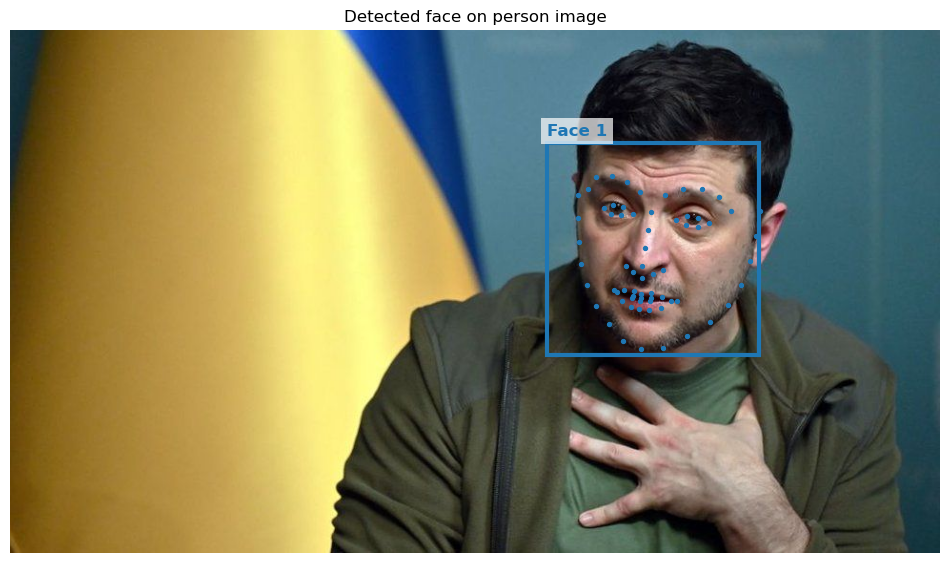

In [12]:
draw_faces(
    person_img,
    person_results,
    title="Detected face on person image",
    draw_landmarks=True
)


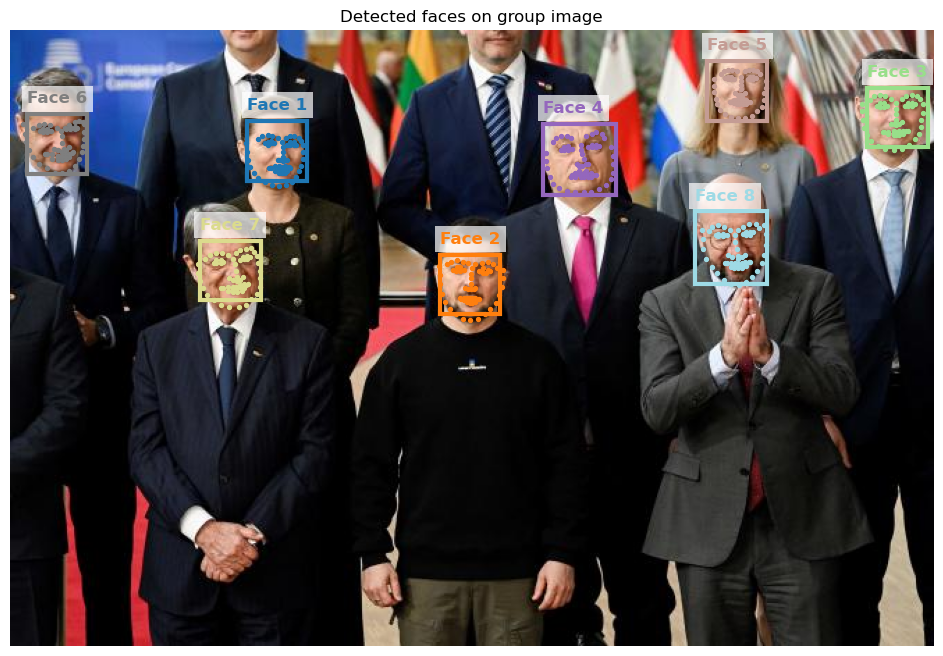

In [13]:
draw_faces(
    group_img,
    group_results,
    title="Detected faces on group image",
    draw_landmarks=True
)


Optional: find the same person in a group photo

In [14]:

FACE_RECOGNITION_MODEL_PATH = Path("dlib_face_recognition_resnet_model_v1.dat")

download_and_extract_bz2(
    url="http://dlib.net/files/dlib_face_recognition_resnet_model_v1.dat.bz2",
    output_path=FACE_RECOGNITION_MODEL_PATH
)

face_recognition_model = dlib.face_recognition_model_v1(str(FACE_RECOGNITION_MODEL_PATH))


Extracting model...
Done: dlib_face_recognition_resnet_model_v1.dat


In [16]:
def get_face_descriptor(image_rgb, face_result):
    # Creates a 128-dimensional descriptor for a single face

    rect = face_result["rect"]
    shape = shape_predictor(image_rgb, rect)
    descriptor = face_recognition_model.compute_face_descriptor(image_rgb, shape)
    return np.array(descriptor)


In [17]:
def get_largest_face_result(results):
    #If multiple faces are found in the image of one person, we take the largest one

    if len(results) == 0:
        raise ValueError("No faces were found in the image.")

    def face_area(result):
        rect = result["rect"]
        return (rect.right() - rect.left()) * (rect.bottom() - rect.top())

    return max(results, key=face_area)


In [18]:
target_face = get_largest_face_result(person_results)
target_descriptor = get_face_descriptor(person_img, target_face)

print("Target descriptor shape:", target_descriptor.shape)


Target descriptor shape: (128,)


In [19]:
def compare_faces(target_descriptor, image_rgb, face_results, threshold=0.6):
    # Compares target_descriptor with all faces in a group photo

    comparisons = []

    for idx, result in enumerate(face_results):
        descriptor = get_face_descriptor(image_rgb, result)
        distance = np.linalg.norm(target_descriptor - descriptor)
        is_match = distance < threshold

        comparisons.append({
            "face_index": idx,
            "rect": result["rect"],
            "landmarks": result["landmarks"],
            "distance": distance,
            "is_match": is_match
        })

    return comparisons


In [20]:
comparisons = compare_faces(
    target_descriptor=target_descriptor,
    image_rgb=group_img,
    face_results=group_results,
    threshold=0.6
)

for item in comparisons:
    print(
        f"Face {item['face_index'] + 1}: "
        f"distance = {item['distance']:.3f}, "
        f"match = {item['is_match']}"
    )


Face 1: distance = 0.961, match = False
Face 2: distance = 0.418, match = True
Face 3: distance = 0.802, match = False
Face 4: distance = 0.704, match = False
Face 5: distance = 0.981, match = False
Face 6: distance = 0.700, match = False
Face 7: distance = 0.668, match = False
Face 8: distance = 0.711, match = False


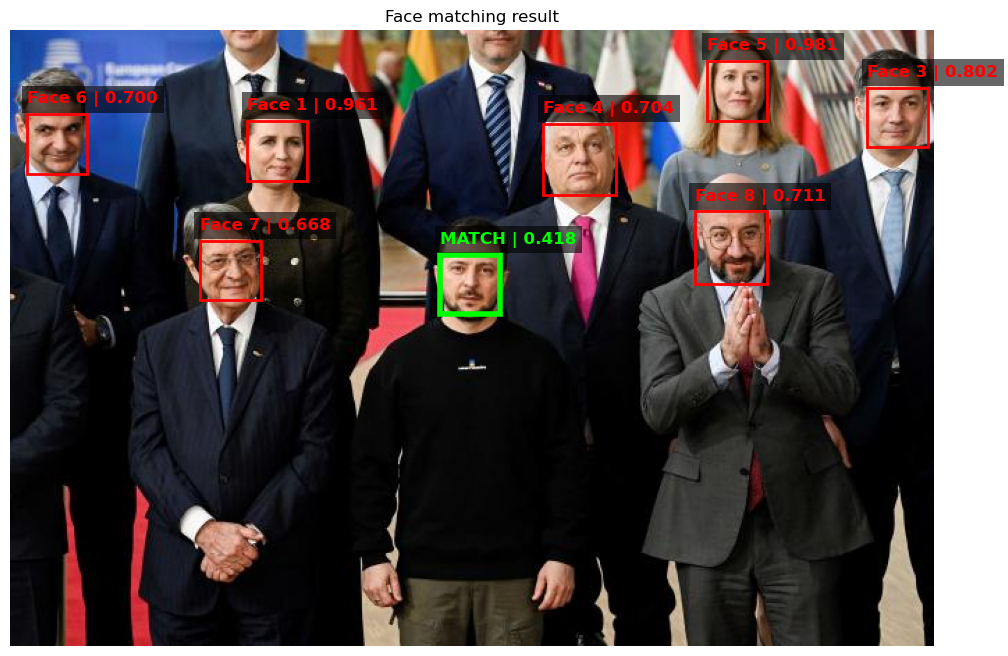

In [21]:
def draw_face_matching_results(image_rgb, comparisons):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(image_rgb)
    ax.axis("off")
    ax.set_title("Face matching result")

    for item in comparisons:
        rect = item["rect"]
        distance = item["distance"]
        is_match = item["is_match"]
        face_index = item["face_index"]

        x = rect.left()
        y = rect.top()
        w = rect.right() - rect.left()
        h = rect.bottom() - rect.top()

        if is_match:
            color = "lime"
            label = f"MATCH | {distance:.3f}"
            linewidth = 4
        else:
            color = "red"
            label = f"Face {face_index + 1} | {distance:.3f}"
            linewidth = 2

        box = Rectangle(
            (x, y),
            w,
            h,
            linewidth=linewidth,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(box)

        ax.text(
            x,
            y - 8,
            label,
            color=color,
            fontsize=12,
            weight="bold",
            bbox=dict(facecolor="black", alpha=0.6, edgecolor="none")
        )

    plt.show()

draw_face_matching_results(group_img, comparisons) 



In [69]:
def median_filter(img, kernel_size=3):
    # Median filter
    if kernel_size % 2 == 0:
        raise ValueError("kernel_size must be odd")

    r = kernel_size // 2

    if img.ndim == 2:
        padded = np.pad(img, ((r, r), (r, r)), mode="edge")
        windows = sliding_window_view(padded, (kernel_size, kernel_size))
        return np.median(windows, axis=(-2, -1)).astype(np.uint8)

    padded = np.pad(img, ((r, r), (r, r), (0, 0)), mode="edge")
    windows = sliding_window_view(padded, (kernel_size, kernel_size), axis=(0, 1))
    return np.median(windows, axis=(-2, -1)).astype(np.uint8)


STRUCT_ELEMENT = np.array([
    [0, 0, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [1, 1, 1, 1, 1],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0]
], dtype=bool)


Step 5. Перевірка на складнішому зображенні

Faces detected: 34


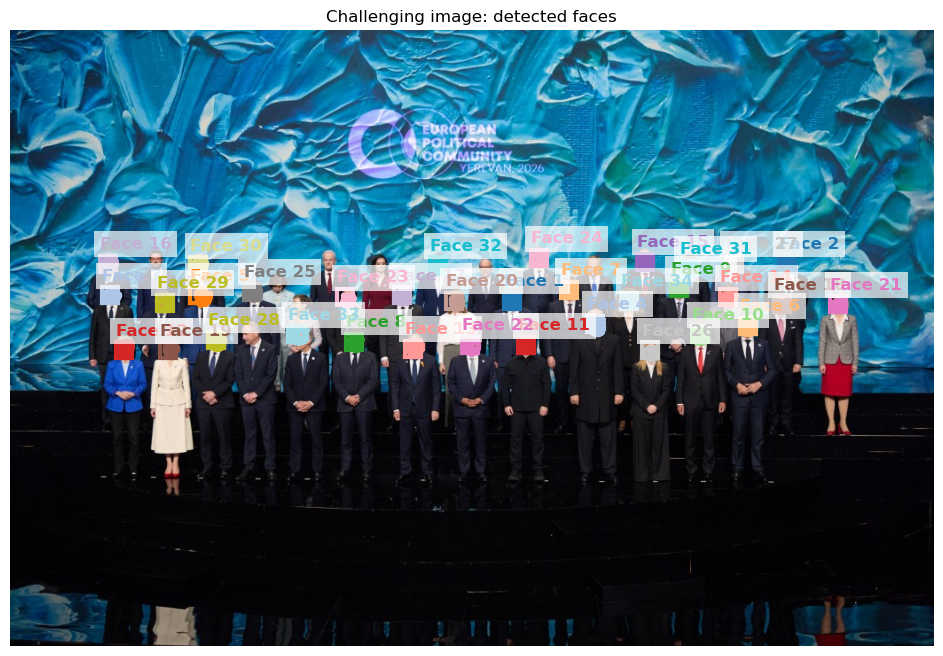

In [22]:
CHALLENGING_IMAGE_PATH = "group2.jpeg"

challenging_img = load_image_rgb(CHALLENGING_IMAGE_PATH)
challenging_results = detect_faces_and_landmarks(challenging_img, upsample_times=2)

print(f"Faces detected: {len(challenging_results)}")

draw_faces(
    challenging_img,
    challenging_results,
    title="Challenging image: detected faces",
    draw_landmarks=True
)


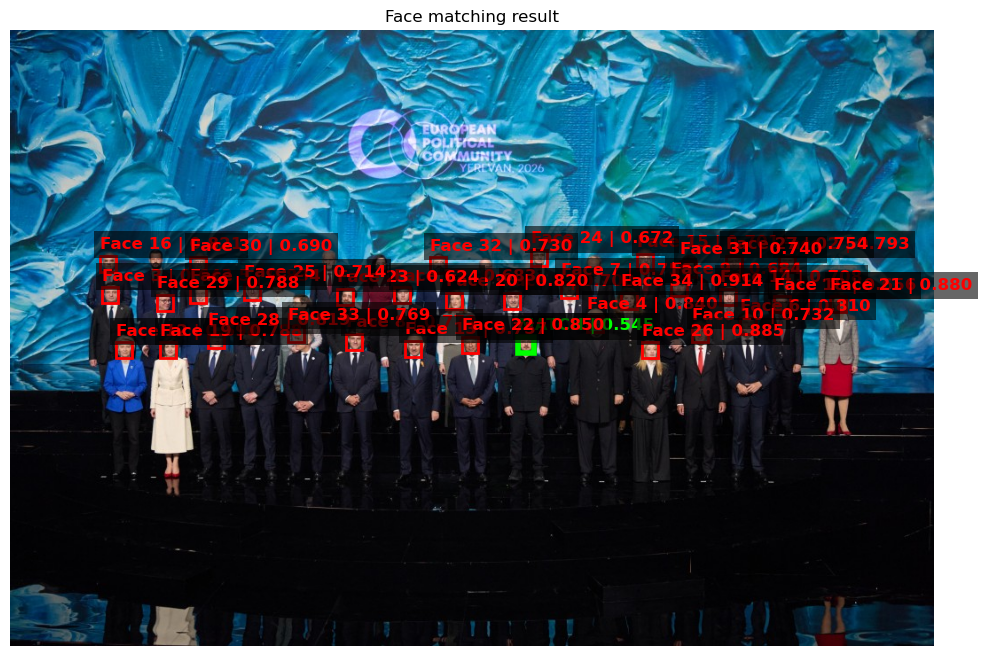

In [23]:
challenging_comparisons = compare_faces(
    target_descriptor=target_descriptor,
    image_rgb=challenging_img,
    face_results=challenging_results,
    threshold=0.6
)

draw_face_matching_results(challenging_img, challenging_comparisons)
